<a href="https://colab.research.google.com/github/libiyashri/aiml_assignment/blob/main/Decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving test_scores.csv to test_scores (1).csv
Dataset Preview:
     name  math  cs
0   david    92  98
1   laura    56  68
2  sanjay    88  81
3     wei    70  80
4    jeff    80  83

MSE: 462.6666666666667
R2 Score: -7.132812499999998


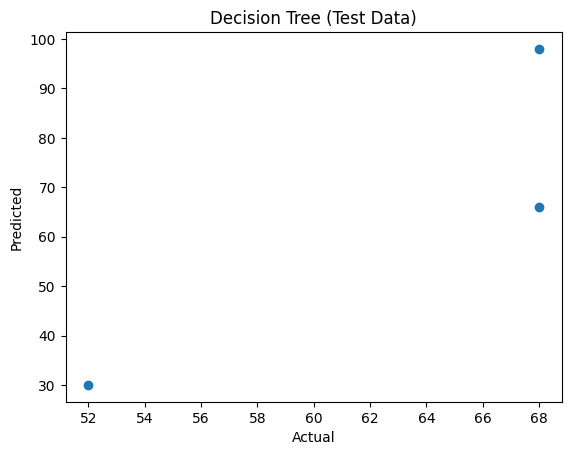

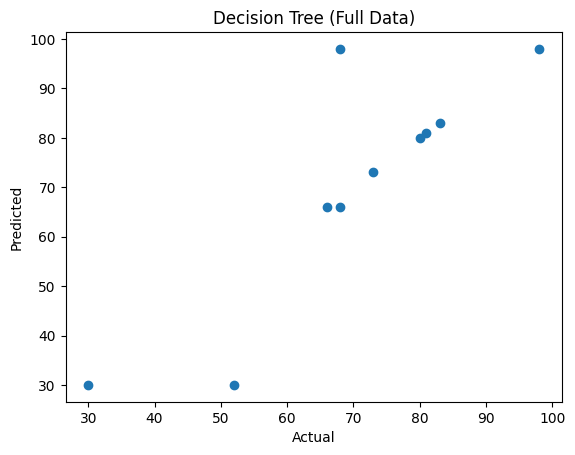

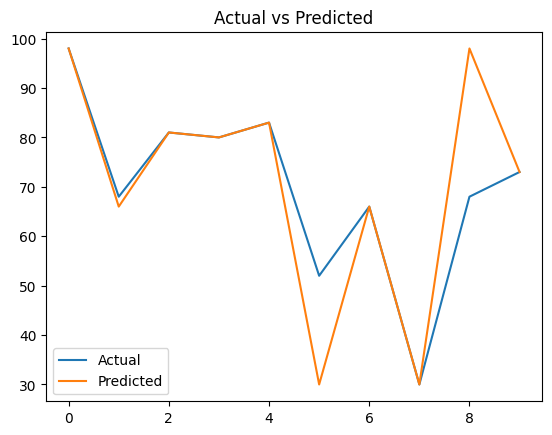

In [ ]:
# ===============================
# 📌 Decision Tree - Simple Code
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ===============================
# 📌 Upload Dataset
# ===============================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset Preview:")
print(df.head())

# ===============================
# 📌 Handle Text Data (if any)
# ===============================
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ===============================
# 📌 Split Data
# ===============================
X = df.iloc[:, :-1]   # input
y = df.iloc[:, -1]    # output

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ===============================
# 📌 Train Model
# ===============================
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# ===============================
# 📌 Prediction
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 📌 Evaluation
# ===============================
print("\nMSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# ===============================
# 📌 Graph (Test Data)
# ===============================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree (Test Data)")
plt.show()

# ===============================
# 📌 Full Data Graph (More Points)
# ===============================
y_full = model.predict(X)

plt.figure()
plt.scatter(y, y_full)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree (Full Data)")
plt.show()

# ===============================
# 📌 Line Graph
# ===============================
plt.figure()
plt.plot(y.values, label="Actual")
plt.plot(y_full, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()